# Quantum tunneling and the WKB approximation (Griffiths QM Ch. 8)
### a particle gets through a wall it classically cannot -- exponentially

Classically a particle with energy $E$ stops at a wall where $V>E$. Quantum-mechanically
the wavefunction does not stop -- it **decays** as $e^{-\kappa x}$,
$\kappa=\sqrt{2m(V-E)}/\hbar$, and a little leaks out the far side. The transmission
through a thick barrier is
$$T\approx e^{-2\gamma},\qquad \gamma=\int_{\text{forbidden}}\!\kappa(x)\,dx\quad(\text{WKB}),$$
and the exact rectangular-barrier formula confirms the same exponential. That
exponential sensitivity is the engine of the scanning tunneling microscope, alpha
decay, the tunnel diode, and flash memory -- the quantum sequel to the band theory in
`dgs.kronig_penney`. Uses `dgs/tunneling.py`. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import tunneling as tn
print("ready")

ready


## 1. The wavefunction penetrates the barrier

Energy $E$ below the barrier top $V_0$: outside, the wave oscillates; **inside**, it
decays as $e^{-\kappa x}$ over a penetration depth $1/\kappa$. A thinner or lower barrier
lets more amplitude reach the far side -- that surviving tail is the tunneling.

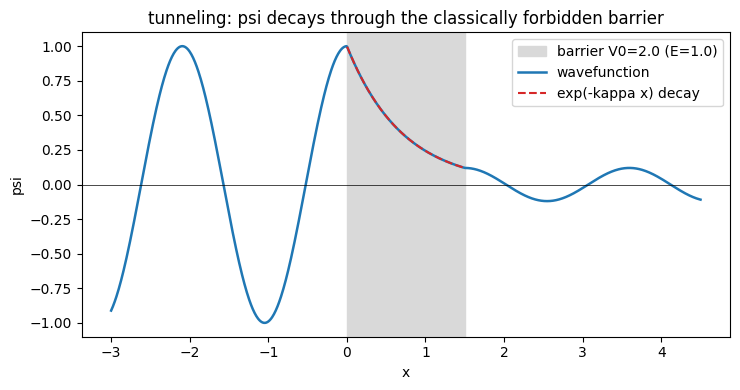

kappa = 1.414, penetration depth 1/kappa = 0.707


In [2]:
E, V0 = 1.0, 2.0; a = 1.5
x = np.linspace(-3, 3+a, 1000)
k = tn.barrier_decay_constant(E, V0)
# schematic wavefunction: incident sine, exponential decay in [0,a], smaller transmitted sine
psi = np.where(x < 0, np.cos(3*x),
       np.where(x <= a, np.cos(0)*np.exp(-k*x), np.exp(-k*a)*np.cos(3*(x-a))))
plt.figure(figsize=(7.5,4))
plt.axvspan(0, a, color="0.85", label=f"barrier V0={V0} (E={E})")
plt.plot(x, psi, lw=1.8, label="wavefunction")
plt.plot(x[(x>=0)&(x<=a)], np.exp(-k*x[(x>=0)&(x<=a)]), "C3--", label="exp(-kappa x) decay")
plt.axhline(0, color="k", lw=0.5); plt.xlabel("x"); plt.ylabel("psi"); plt.legend()
plt.title("tunneling: psi decays through the classically forbidden barrier"); plt.tight_layout(); plt.show()
print(f"kappa = {k:.3f}, penetration depth 1/kappa = {1/k:.3f}")

## 2. Transmission falls off exponentially with width

Plot the exact transmission and the WKB estimate vs barrier width on a log axis -- a
straight line of slope $-2\kappa$. WKB tracks the exponent; the exact curve adds a slowly
varying prefactor. A factor-of-two-thicker barrier can cut the tunneling by orders of
magnitude.

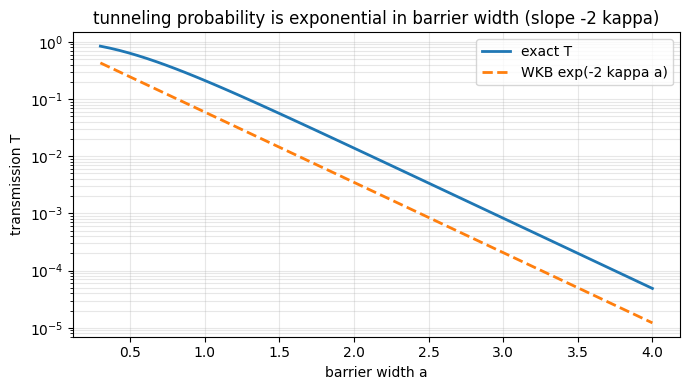

ratio exact/WKB at a=4 = 4.00  (the prefactor 16 E(V0-E)/V0^2 = 4)


In [3]:
widths = np.linspace(0.3, 4, 60)
Te = [tn.rectangular_barrier_T(E, V0, a) for a in widths]
Tw = [tn.wkb_transmission(E, np.full(400, V0), np.linspace(0, a, 400)) for a in widths]
plt.figure(figsize=(7,4))
plt.semilogy(widths, Te, lw=2, label="exact T")
plt.semilogy(widths, Tw, "--", lw=2, label="WKB exp(-2 kappa a)")
plt.xlabel("barrier width a"); plt.ylabel("transmission T"); plt.legend()
plt.title("tunneling probability is exponential in barrier width (slope -2 kappa)")
plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()
print(f"ratio exact/WKB at a=4 = {tn.rectangular_barrier_T(E,V0,4)/tn.wkb_transmission(E,np.full(800,V0),np.linspace(0,4,800)):.2f}"
      f"  (the prefactor 16 E(V0-E)/V0^2 = {16*E*(V0-E)/V0**2:.0f})")

## 3. WKB handles a smooth barrier -- just integrate kappa(x)

For a non-rectangular barrier there is no simple closed form, but WKB still works: add
up $\kappa(x)$ across wherever $V(x)>E$. Here a triangular barrier -- the integral over
its varying height gives the transmission.

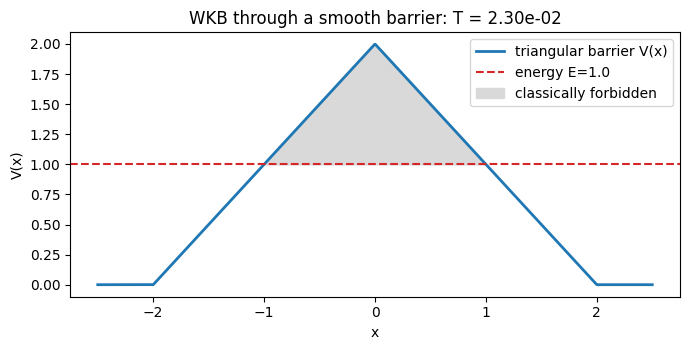

In [4]:
xt = np.linspace(-2.5, 2.5, 800)
Vtri = np.maximum(0.0, V0*(1 - np.abs(xt)/2.0))           # triangular peak V0 at x=0
T_tri = tn.wkb_transmission(E, Vtri, xt)
plt.figure(figsize=(7,3.6))
plt.plot(xt, Vtri, lw=2, label="triangular barrier V(x)")
plt.axhline(E, color="C3", ls="--", label=f"energy E={E}")
plt.fill_between(xt, E, Vtri, where=Vtri>E, color="0.85", label="classically forbidden")
plt.xlabel("x"); plt.ylabel("V(x)"); plt.legend()
plt.title(f"WKB through a smooth barrier: T = {T_tri:.2e}"); plt.tight_layout(); plt.show()

## 4. What tunneling powers -- the scanning tunneling microscope

STM current $\propto e^{-2\kappa d}$ in the tip-sample gap $d$. With a typical
$\kappa\approx1\,\text{\AA}^{-1}$, moving the tip **one angstrom** changes the current by
$e^{2}\approx7\times$ -- so the microscope feels individual atoms. That brutal
exponential sensitivity, a liability for a barrier, is the whole instrument.

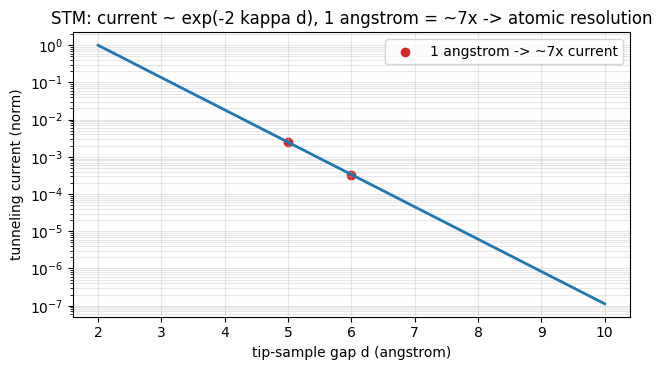

e^2 = 7.39 -> a 1-angstrom gap change is one order-of-magnitude in current


In [5]:
kappa_stm = 1.0          # 1/angstrom (typical metal work function)
d = np.linspace(2, 10, 100)                                # tip-sample gap in angstrom
current = np.exp(-2*kappa_stm*d)
plt.figure(figsize=(6.5,3.8))
plt.semilogy(d, current/current[0], lw=2)
plt.scatter([5,6],[np.exp(-2*5)/np.exp(-4), np.exp(-2*6)/np.exp(-4)], color="C3",
            label="1 angstrom -> ~7x current")
plt.xlabel("tip-sample gap d (angstrom)"); plt.ylabel("tunneling current (norm)"); plt.legend()
plt.title("STM: current ~ exp(-2 kappa d), 1 angstrom = ~7x -> atomic resolution")
plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()
print("e^2 =", round(np.e**2, 2), "-> a 1-angstrom gap change is one order-of-magnitude in current")

## Takeaway

1. A wavefunction **penetrates** a classically forbidden barrier, decaying as
   $e^{-\kappa x}$, $\kappa=\sqrt{2m(V-E)}/\hbar$.
2. The transmission is **exponential**, $T\sim e^{-2\gamma}$ (WKB), confirmed by the exact
   rectangular-barrier formula (same exponent, an $O(1)$ prefactor).
3. That exponential sensitivity **is** the scanning tunneling microscope, alpha decay
   (Gamow), the tunnel diode, and flash-memory programming.

Tunneling is the quantum follow-on to band theory: in `kronig_penney` electrons live in
bands; here they leak through the gaps. Civilian education / Griffiths QM Ch. 8.